# Data loading

In [22]:
import torch
import torch.nn.functional as F

import os
from pathlib import Path

from torchvision.datasets import CelebA

#CLIP
from transformers import CLIPProcessor, CLIPModel
from PIL import Image


import numpy as np
from tqdm import tqdm

In [34]:
DEVICE = "cpu"

SPLITS = ["all", "train", "valid", "test"]

ATTRIBUTE_PATH = Path("./Celeba/celeba/list_attr_celeba.txt")

In [ ]:
data_root = Path("./Celeba")


In [10]:
celeba_train = CelebA(root=data_root, split="train", download=False)
celeba_valid = CelebA(root=data_root, split="valid", download=False)
celeba_test = CelebA(root=data_root, split="test", download=False)
celeba_all = CelebA(root=data_root, split="all", download=False)

In [ ]:
print(f"TRAINING SET: {len(celeba_train)}")
print(f"VALIDATION SET: {len(celeba_valid)}")
print(f"TEST SET: {len(celeba_test)}")
print(f"FULL SET: {len(celeba_all)}")

TRAINING SET: 162770
VALIDATION SET: 19867
TEST SET: 19962
FULL SET: 202599


In [11]:
print(celeba_train.split)

train


# Metrics

In [18]:
def evaluate_retrieval(
    retrieved_indices: list[int],
    ground_truth_indices: list[int],
    k: int
):
    """
    Evaluate the retrieval performance for a single source image.

    Args:
    ----
        retrieved_indices: list of image IDs predicted by the model,
            ordered by similarity (descending).
        ground_truth_indices: list of valid target IDs from the benchmark JSON.
        k: the cutoff for top-K evaluation (e.g., 1, 5, 10).

    Return:
    ------
        A dictionary containing Recall@K and Precision@K.

    """
    # Isolate the top K predictions
    top_k_retrieved = retrieved_indices[:k]

    # Calculate the intersection between predictions and ground truth
    hits = set(top_k_retrieved).intersection(set(ground_truth_indices))
    num_hits = len(hits)

    # Metrics calculations
    # Recall@K (Hit Rate): 1 if at least one match is found, 0 otherwise
    recall_at_k = 1 if num_hits > 0 else 0

    # Precision@K: Fraction of top K predictions that are correct
    precision_at_k = num_hits / k

    return {
        f"Recall@{k}": recall_at_k,
        f"Precision@{k}": precision_at_k
    }

In [19]:
# --- Example Usage ---
# Suppose the model returns these indices from most to least similar:
predictions = [1, 2, 3, 4, 5]
# And we load this from our JSON for this specific source:
ground_truth = [3, 2, 1]

# Evaluate at K=1 and K=5
print("Results @ 1:", evaluate_retrieval(predictions, ground_truth, k=1))
print("Results @ 5:", evaluate_retrieval(predictions, ground_truth, k=5))

Results @ 1: {'Recall@1': 1, 'Precision@1': 1.0}
Results @ 5: {'Recall@5': 1, 'Precision@5': 0.6}


# Evaluation

In [20]:
import json

In [21]:
annotations_path = Path("celeba_evaluation.json")

with open(annotations_path, "r") as f:
    annotations = json.load(f)

len(annotations)

14

In [22]:
# `annotations` is a list of queries
# Each query is a dictionary with these keys:
# - `query`: the textual query itself
# - `ground_truth`: a dictionary of images
#
# Each element in `ground_truth` is structured as:
# {
#    idx: list[int]
# }
# `idx` is the source image that you have to use together with the `query`
# `list[int]` is the list of acceptable target images, i.e., the images
# that you should retrieve

print(annotations[0].keys())
print()
print("Query:", annotations[0]["query"])
print("Source images:", len(annotations[0]["ground_truth"].keys()))

dict_keys(['query', 'ground_truth'])

Query: +Smiling
Source images: 4786


# Misc

In [34]:
# Unique index to each attribute, and inverse mapping
idx2attribute = {idx: name for idx, name in enumerate(celeba_test.attr_names)}
attribute2idx = {name: idx for idx, name in enumerate(celeba_test.attr_names)}

(<PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=178x218 at 0x7F7C6C30F750>, tensor([0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0,
        1, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1]))
tensor([0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0,
        1, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1])


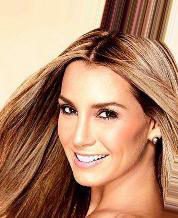

In [42]:
print(celeba_all[0])
print(celeba_all[0][1])
celeba_all[0][0]



In [ ]:
def matches(query, split=celeba_all):
    """
        Takes an attribute query in the form query[i] = +/-Attribute and returns the images that match it
    """

    considered_attributes = []
    n_matches = 0
    matches = []
    is_candidate = False

    for element in query:
        if element[0] == '+':
            considered_attributes.append([attribute2idx[element[1:]], 1])
        elif element[0] == '-':
            considered_attributes.append([attribute2idx[element[1:]], 0])
        else:
            print("Query formulation error")
            return

    print(considered_attributes)

    
    for individual in split:
        is_candidate = False
        for element in considered_attributes:
            if individual[1][element[0]] != element[1]:
                is_candidate = False
                break
            is_candidate = True
        if is_candidate:
            n_matches += 1
            matches.append(individual)

    return n_matches, matches

In [76]:
matches(["+Bald", "+No_Beard"], celeba_test)

[[4, 1], [24, 1]]


(253,
 [(<PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=178x218>,
   tensor([0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0,
           1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0])),
  (<PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=178x218>,
   tensor([0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0,
           1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0])),
  (<PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=178x218>,
   tensor([0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0,
           1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])),
  (<PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=178x218>,
   tensor([0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0,
           1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0])),
  (<PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=178x218>,
   tensor([0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 

/home/dfrailis/anaconda3/lib/python3.13/site-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


In [29]:
def atomic_torch_save(value, path:Path):
    path.parent.mkdir(parents=True, exist_ok=True)
    tmp = path.with_suffix(path.suffix+".tmp")
    torch.save(value, tmp)
    os.replace(tmp, path)

def read_attribute_table():
    path = ATTRIBUTE_PATH

    with path.open(encoding="utf-8") as handle:
        _ = int(handle.readline().strip())
        names = [name for name in handle.readline().split() if name]

        filenames = []
        rows = []

        for line in handle:
            parts = line.split()
            if parts:
                filenames.append(parts[0])
                rows.append([1 if int(value)==1 else -1 for value in parts[1:]])

        if len(names) != 40:
            raise RuntimeError(f"Expected 40 CelebA attributes, found {len(names)}")
    return names, filenames, torch.tensor(rows, dtype=torch.int8)
            
            

In [30]:

def create_image_embeddings(dataset_split , device=DEVICE, output="./embeddingg"):
    """
        create an offline database of the embeddings of the celeba images passed through CLIP
    """
    model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32")
    processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

    output_dir = Path(output)
    output_dir.mkdir(exist_ok=True)
    output_path = output_dir / f"{dataset_split.split}_image_embeddings.pt"

    embeddings, filenames = [], []
    image_root = data_root / "celeba" / "img_align_celeba"

    with torch.inference_mode():
        for start in range(0, len(dataset_split.filename), 128):
            names = list(dataset_split.filename[start:start+128])
            images = [Image.open(image_root/name).convert("RGB") for name in names]
            inputs = processor(images=images, return_tensors="pt", padding=True).to(device)
            feats = model.get_image_features(**inputs)
            embeddings.append(F.normalize(feats, dim=-1).cpu())
            filenames.extend(names)

    atomic_torch_save({"model_id": "clip-vit-base-patch32", "split":dataset_split.split, "filenames":filenames, "embeddings":torch.cat(embeddings)}, output_path)
    return output_path

In [27]:
def prompt_pair(attribute):
    special = {"Attractive": ("an attractive face", "an unattractive face"),
               "Bald": ("a bald person", "a person with hair"),
               "Blurry": ("a blurry face photo", "a sharp face photo"),
               "Chubby": ("a chubby face", "a slim face"),
               "Male": ("a male face", "a female face"),
               "Smiling": ("a smiling face", "a face that is not smiling"),
               "Young": ("a young face", "an older face")}

    if attribute in special:
        return special[attribute]
    else:
        readable = attribute.replace("_", " ").lower()
        return f"a face with {readable}", f"a face without {readable}"

def create_prompt_embeddings(device=DEVICE, output="./embeddingg"):
    attrs, _, _ = read_attribute_table()

    model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32")
    processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

    positives, negatives = zip(*(prompt_pair(attr) for attr in attrs))

    with torch.inference_mode():
        pos_inputs = processor(text=list(positives), return_tensors="pt", padding=True).to(device)
        neg_inputs = processor(text=list(negatives), return_tensors="pt", padding=True).to(device)

        pos = F.normalize(model.get_text_features(**pos_inputs), dim=-1).cpu()
        neg = F.normalize(model.get_text_features(**neg_inputs), dim=-1).cpu()

    directions = F.normalize(pos - neg, dim=-1)

    output_dir = Path(output)
    output_dir.mkdir(exist_ok=True)
    output_path = output_dir / "signed_attribute_prompt_embeddings"

    atomic_torch_save({"model_id": "clip-vit-base-patch32", "attributes": attrs, "positive": pos, "negative": neg, "directions": directions}, output_path)
    return output_path

In [36]:
names, filenames, rows = read_attribute_table()

In [37]:
print(names)

['5_o_Clock_Shadow', 'Arched_Eyebrows', 'Attractive', 'Bags_Under_Eyes', 'Bald', 'Bangs', 'Big_Lips', 'Big_Nose', 'Black_Hair', 'Blond_Hair', 'Blurry', 'Brown_Hair', 'Bushy_Eyebrows', 'Chubby', 'Double_Chin', 'Eyeglasses', 'Goatee', 'Gray_Hair', 'Heavy_Makeup', 'High_Cheekbones', 'Male', 'Mouth_Slightly_Open', 'Mustache', 'Narrow_Eyes', 'No_Beard', 'Oval_Face', 'Pale_Skin', 'Pointy_Nose', 'Receding_Hairline', 'Rosy_Cheeks', 'Sideburns', 'Smiling', 'Straight_Hair', 'Wavy_Hair', 'Wearing_Earrings', 'Wearing_Hat', 'Wearing_Lipstick', 'Wearing_Necklace', 'Wearing_Necktie', 'Young']
